Figure S9: For eQTL lead variants (left) and pcQTL lead variants (right), the number of tissues that share the lead variant vs the number of tissues in which the QTL’s cluster was mapped for QTLs. For each lead variant, sharing is computed as (number of tissues with the shared lead variant/number of tissues with the shared cluster *100). The mean sharing is the mean value over all lead variants. . pcQTLs are slightly, but statistically significantly, more tissue specific, with lower sharing (Mann-Whitney U p-value = 0.011)

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm 

tqdm.pandas()

# get outputs from a config file
import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append(f'{config["working_dir"]}/{config["code_dir"]}')
from utils import *

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

In [2]:
# Load SuSiE credible sets for eQTLs and pcQTLs
print("Loading SuSiE credible sets...")
eqtl_susie = load_across_tissues(config, load_e_susie)
pcqtl_susie = load_across_tissues(config, load_pc_susie)

print(f"Loaded {len(eqtl_susie)} eQTL credible set variants")
print(f"Loaded {len(pcqtl_susie)} pcQTL credible set variants")

# Function to extract lead variant (max PIP) for each credible set
def get_lead_variants(susie_df):
    # Group by phenotype_id and cs_id, find max PIP
    lead_variants = susie_df.loc[susie_df.groupby(['phenotype_id', 'cs_id', 'tissue_id'])['pip'].idxmax()].copy()
    lead_variants['cluster_id'] = lead_variants['phenotype_id'].str.split('_e_').str[0].str.split('_pc').str[0]
    lead_variants['chr'] = lead_variants['variant_id'].str.split('_').str[0]
    lead_variants['pos'] = lead_variants['variant_id'].str.split('_').str[1].astype(int)
    return lead_variants

# Extract lead variants
eqtl_leads = get_lead_variants(eqtl_susie)
pcqtl_leads = get_lead_variants(pcqtl_susie)

print(f"Found {len(eqtl_leads)} eQTL lead variants")
print(f"Found {len(pcqtl_leads)} pcQTL lead variants")
qtl_leads = pd.concat([eqtl_leads, pcqtl_leads], keys=['eQTL', 'pcQTL'], axis=0).reset_index(level=0).rename(columns={'level_0': 'qtl_type'})

# calculate sharing
lead_var_sharing = qtl_leads.groupby(['cluster_id', 'variant_id']).agg({'tissue_id': 'nunique'}).reset_index().rename(columns={'tissue_id': 'num_tissues'})
cluster_sharing = qtl_leads.groupby(['cluster_id']).agg({'tissue_id': 'nunique'}).reset_index().rename(columns={'tissue_id': 'num_tissues'})
merged_sharing = pd.merge(lead_var_sharing, cluster_sharing, on='cluster_id', how='left', suffixes=('_shared_lead_var', '_shared_cluster'))

Loading SuSiE credible sets...
Loaded 455306 eQTL credible set variants
Loaded 443922 pcQTL credible set variants
Found 19166 eQTL lead variants
Found 18149 pcQTL lead variants


p-value for the difference in mean sharing ratios (eQTL vs pcQTL): 1.085e-02


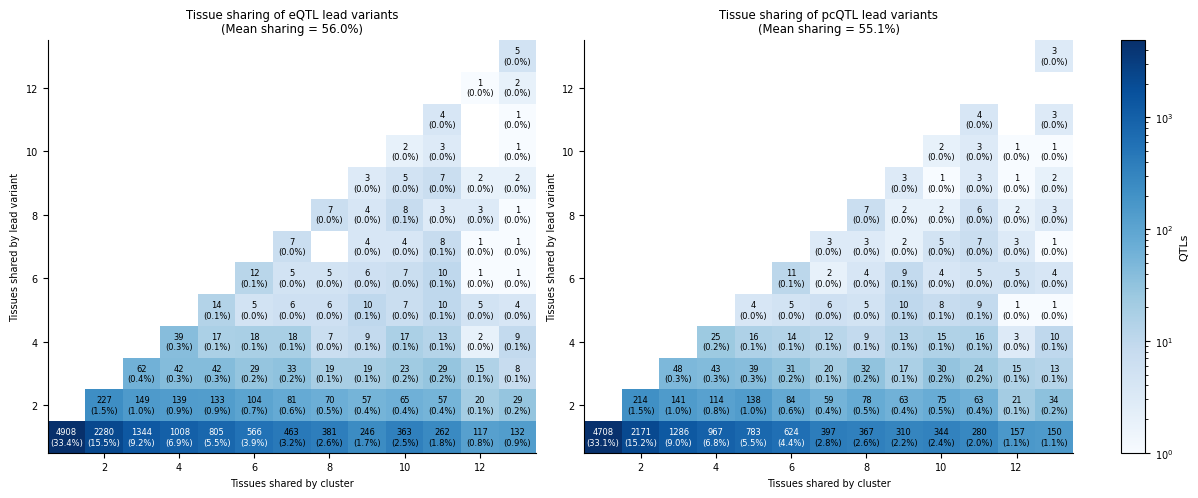

In [10]:
def compute_merged_sharing(leads_df):
    lead_var_sharing = leads_df.groupby(['cluster_id', 'variant_id']).agg({'tissue_id': 'nunique'}).reset_index().rename(columns={'tissue_id': 'num_tissues'})
    cluster_sharing = leads_df.groupby(['cluster_id']).agg({'tissue_id': 'nunique'}).reset_index().rename(columns={'tissue_id': 'num_tissues'})
    merged = pd.merge(lead_var_sharing, cluster_sharing, on='cluster_id', how='left', suffixes=('_shared_lead_var', '_shared_cluster'))
    return merged

merged_sharing_eqtl = compute_merged_sharing(eqtl_leads)
merged_sharing_pcqtl = compute_merged_sharing(pcqtl_leads)

# Calculate sharing ratios for each dataset
merged_sharing_eqtl['sharing_ratio'] = merged_sharing_eqtl['num_tissues_shared_lead_var'] / merged_sharing_eqtl['num_tissues_shared_cluster']
merged_sharing_pcqtl['sharing_ratio'] = merged_sharing_pcqtl['num_tissues_shared_lead_var'] / merged_sharing_pcqtl['num_tissues_shared_cluster']

# Calculate Mann-Whitney U test p-value for the difference in sharing ratios
u_stat, pval = mannwhitneyu(merged_sharing_eqtl['sharing_ratio'], merged_sharing_pcqtl['sharing_ratio'], alternative='two-sided')
print(f"p-value for the difference in mean sharing ratios (eQTL vs pcQTL): {pval:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1, 0.05]}, sharey=False)
ax1, ax2, ax_cbar = axes

mean_ratio_eqtl = merged_sharing_eqtl['sharing_ratio'].mean()
mean_ratio_pcqtl = merged_sharing_pcqtl['sharing_ratio'].mean()

# Get bin edges for consistency
eqtl_x = merged_sharing_eqtl['num_tissues_shared_cluster']
eqtl_y = merged_sharing_eqtl['num_tissues_shared_lead_var']
pcqtl_x = merged_sharing_pcqtl['num_tissues_shared_cluster']
pcqtl_y = merged_sharing_pcqtl['num_tissues_shared_lead_var']

all_x = pd.concat([eqtl_x, pcqtl_x])
all_y = pd.concat([eqtl_y, pcqtl_y])
x_bins = np.arange(all_x.min(), all_x.max() + 2) - 0.5
y_bins = np.arange(all_y.min(), all_y.max() + 2) - 0.5

# Compute histograms
counts_eqtl, xedges, yedges = np.histogram2d(eqtl_x, eqtl_y, bins=[x_bins, y_bins])
counts_pcqtl, _, _ = np.histogram2d(pcqtl_x, pcqtl_y, bins=[x_bins, y_bins])

# Mask zeros for log scale
counts_eqtl_masked = np.where(counts_eqtl > 0, counts_eqtl, np.nan)
counts_pcqtl_masked = np.where(counts_pcqtl > 0, counts_pcqtl, np.nan)

# Normalize bins with LogNorm, setting vmin to 1 for log scale zero handling
vmax = np.nanmax([counts_eqtl_masked, counts_pcqtl_masked])
vmin = 1

# Plot for eQTL (left)
cmap = mpl.colormaps['Blues'] if hasattr(mpl, 'colormaps') else mpl.cm.Blues

mesh_eqtl = ax1.pcolormesh(
    xedges, yedges, counts_eqtl_masked.T, 
    cmap="Blues", norm=LogNorm(vmin=vmin, vmax=vmax)
)
# Plot for pcQTL (right)
mesh_pcqtl = ax2.pcolormesh(
    xedges, yedges, counts_pcqtl_masked.T, 
    cmap="Blues", norm=LogNorm(vmin=vmin, vmax=vmax)
)

# Colorbar
cb = fig.colorbar(mesh_pcqtl, cax=ax_cbar)
cb.set_label('QTLs', fontsize=8)
cb.ax.tick_params(labelsize=7)

# Annotate counts and percentages for each, using white text if background is dark
for ax, counts, xedges_, yedges_, mesh in zip(
        [ax1, ax2], 
        [counts_eqtl, counts_pcqtl], 
        [xedges]*2, [yedges]*2,
        [mesh_eqtl, mesh_pcqtl]
    ):
    total_count = counts.sum()
    # Get the normalization and colormap from the mesh
    norm = mesh.norm
    cm = mesh.get_cmap()
    for i in range(len(xedges_) - 1):
        for j in range(len(yedges_) - 1):
            count = int(counts[i, j])
            if count > 0 and total_count > 0:
                percent = 100 * count / total_count
                # Get normalized color for this bin
                color_val = norm(count)
                rgba = to_rgba(cm(color_val))
                # Calculate luminance (perceived brightness)
                R, G, B, _ = rgba
                luminance = 0.299 * R + 0.587 * G + 0.114 * B
                text_color = 'white' if luminance < 0.4 else 'black'
                ax.text(
                    xedges_[i] + 0.5,
                    yedges_[j] + 0.5,
                    f"{count}\n({percent:.1f}%)",
                    color=text_color,
                    ha='center',
                    va='center', 
                    fontsize=6
                )
    ax.spines['top'].set_visible(False) 
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Tissues shared by cluster')
    ax.set_ylabel('Tissues shared by lead variant')

# Set plot titles with the mean sharing ratio
ax1.set_title(f'Tissue sharing of eQTL lead variants\n(Mean sharing = {mean_ratio_eqtl*100:.1f}%)')
ax2.set_title(f'Tissue sharing of pcQTL lead variants\n(Mean sharing = {mean_ratio_pcqtl*100:.1f}%)')

plt.tight_layout()
plt.savefig(f"{config['working_dir']}/workflow/supplemental_figures/figures/figure_s9.pdf", 
            transparent=True, bbox_inches='tight', dpi=300)
plt.show()